In [69]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


#### Limpieza caracterizacion

#### Conversion datos academicos a csv

In [70]:
df_datos_academicos = pd.read_excel("../data/desempeño_areas_formacion.xlsx")

df_datos_academicos.to_csv("../data/desempeño_areas_formacion.csv", index=False)

df_datos_academicos = pd.read_excel("../data/df_caracterizacion_recategorizacion_variables.xlsx")

df_datos_academicos.to_csv("../data/df_caracterizacion_recategorizacion_variables.csv", index=False)

#### Union de los datos por cedula

sin duplicados


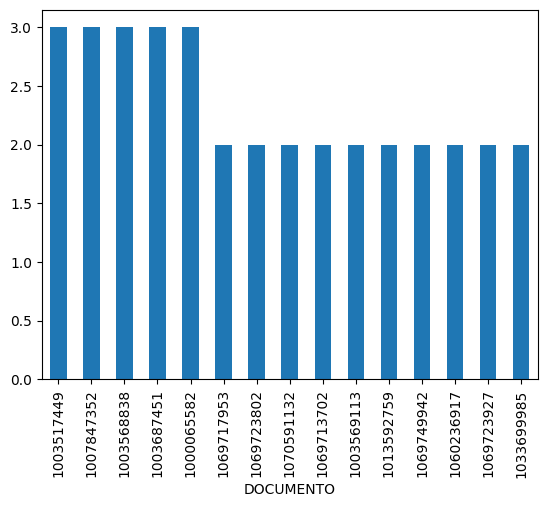

In [71]:
df_caracterizacion = pd.read_csv('../data/desempeño_areas_formacion.csv')

df_datos_academicos = pd.read_csv('../data/df_caracterizacion_recategorizacion_variables_depurada.csv')

# Unirlos por la columna 'cedula'
df_merged = pd.merge(df_caracterizacion, df_datos_academicos, on="DOCUMENTO", how="inner")

df_merged['DOCUMENTO'].value_counts().head(15).plot(kind='bar')

duplicados = df_merged[df_merged.duplicated(keep=False)]
if duplicados.size > 0:
     duplicados.to_csv("../data/df_estudiantes_duplicados.csv", index=False)

df_duplicados = pd.read_csv("../data/df_estudiantes_duplicados.csv")

df_merged[df_merged.duplicated(subset=['DOCUMENTO'], keep=False)]

# Eliminar duplicados por cedula si los hay
df_final = df_merged.drop_duplicates(subset="DOCUMENTO")

duplicados = df_final[df_final.duplicated(keep=False)]

if duplicados.size > 0:
    print(duplicados.DOCUMENTO)
else:
    print("sin duplicados")

# Guardar el resultado
df_final.to_csv("../data/estudiantes_unidos.csv", index=False)


In [72]:
import pandas as pd

def comparar_documento(df, documento):
    registros = df[df['DOCUMENTO'] == documento]
    
    if len(registros) > 1:
        dif_cols = registros.nunique() > 1
        dif_cols = dif_cols[dif_cols].index.tolist()  
        
        if dif_cols:
            subset = registros[['DOCUMENTO'] + dif_cols]

            # === Estilo visual: resalta los valores diferentes ===
            def resaltar_diferencias(x):
                colores = []
                for col in x.columns:
                    if col == 'DOCUMENTO':
                        colores.append([''] * len(x))
                    else:
                        # Marca en amarillo si el valor no es el más común
                        valor_mas_frecuente = x[col].mode()[0]
                        colores.append([
                            'background-color: lightyellow' if v != valor_mas_frecuente else ''
                            for v in x[col]
                        ])
                return pd.DataFrame({c: colores[i] for i, c in enumerate(x.columns)})

            return subset.style.apply(resaltar_diferencias, axis=None)

duplicados = df_duplicados['DOCUMENTO'].value_counts()
duplicados = duplicados[duplicados > 1].index

for doc in duplicados:
    dif = comparar_documento(df_duplicados, doc)
    if dif is not None:
        print(f"\n🔹 Diferencias para DOCUMENTO {doc}:")
        display(dif)  
    else:
         print(f"Sin diferencias")


Sin diferencias
Sin diferencias
Sin diferencias
Sin diferencias
Sin diferencias
Sin diferencias
Sin diferencias
Sin diferencias
Sin diferencias
Sin diferencias
Sin diferencias
Sin diferencias
Sin diferencias
Sin diferencias
Sin diferencias
Sin diferencias
Sin diferencias
Sin diferencias
Sin diferencias
Sin diferencias
Sin diferencias
Sin diferencias
Sin diferencias
Sin diferencias


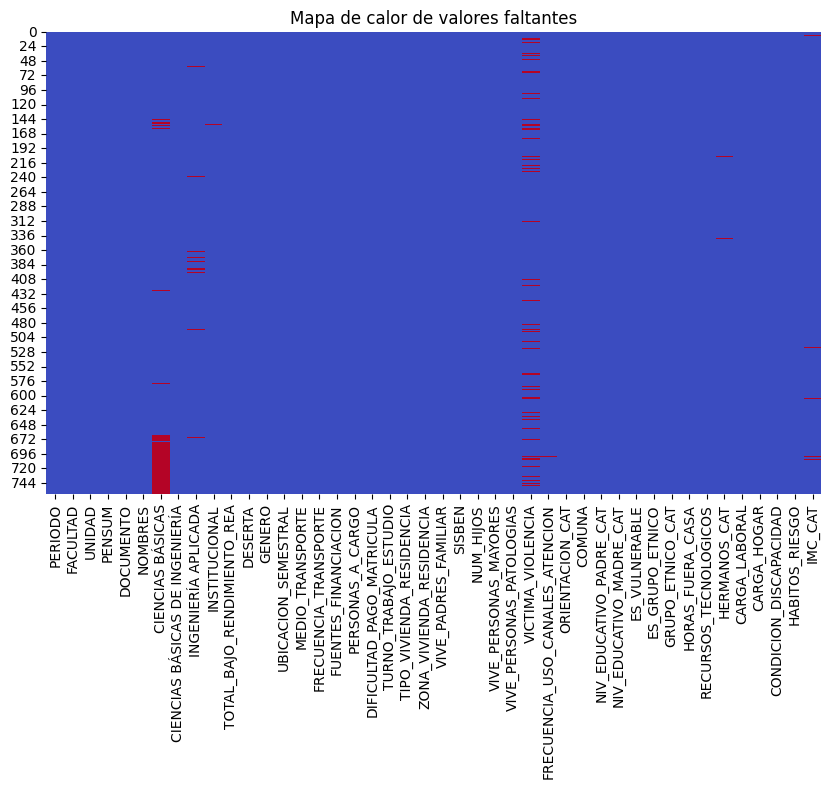

In [73]:
df_estudiantes_unidos =  pd.read_csv('../data/estudiantes_unidos.csv')

plt.figure(figsize=(10, 6))
sns.heatmap(df_estudiantes_unidos.isnull(), cbar=False, cmap='coolwarm')  
plt.title('Mapa de calor de valores faltantes')
plt.show()

In [ ]:
faltantes_ciencias = df_estudiantes_unidos[df_estudiantes_unidos['CIENCIAS BÁSICAS'].isna()]
print(faltantes_ciencias[['UBICACION_SEMESTRAL', 'PENSUM']])

porc_faltantes = df_estudiantes_unidos['VICTIMA_VIOLENCIA'].isna().mean() * 100
print("Porcentaje faltante de VICTIMA_VIOLENCIA %", porc_faltantes)


     UBICACION_SEMESTRAL                                             PENSUM
12                     9  INGENIERIA DE SISTEMAS Y COMPUTACION 2020 FUSA...
145                    9                        INGENIERIA DE SISTEMAS 2013
150                    9                        INGENIERIA DE SISTEMAS 2013
151                    9                        INGENIERIA DE SISTEMAS 2013
154                    8                        INGENIERIA DE SISTEMAS 2013
..                   ...                                                ...
757                    2  INGENIERIA DE SISTEMAS Y COMPUTACION 2020 FUSA...
758                    2  INGENIERIA DE SISTEMAS Y COMPUTACION 2020 FUSA...
759                    2  INGENIERIA DE SISTEMAS Y COMPUTACION 2020 FUSA...
760                    2  INGENIERIA DE SISTEMAS Y COMPUTACION 2020 FUSA...
761                    2  INGENIERIA DE SISTEMAS Y COMPUTACION 2020 FUSA...

[109 rows x 2 columns]
Porcentaje faltante de VICTIMA_VIOLENCIA % 10.62992125984252
